<アイデア>
最小全域木の制約（辺を削除した場合、その辺の片側の点と、もう片側の点が所属する連結成分の頂点間の距離は、削除した辺以上でないといけない）
をもとに、polygon を削除するアイデア。

<アルゴリズム>

- ランダムな Q 点を選択
- 最小全域木を得る
- 各辺に対して連結成分を除去した 2 グループを取得
- 除去した辺の最小距離 d（poly.distance）を取得
- 除去した辺の頂点と、辺の片側が含まれる連結成分の頂点全てのに対して最小距離以上となる領域を計算する
- polygon の centroid から見て polygon の外周までの最大距離を d1 とする
- centroid を中心として d-d1 の円を描く
- 対象 polygon から円を diff する
- polyB + d の領域の diff を取る
- 元の辺間の最小距離が更新されたならもう 1 度やる（収束するまで）

<結論>
ダメっぽい。


In [31]:
IS_ONLINE_JUDGE = False

# =================================
import time

GLOBAL_START_TIME = time.perf_counter()


def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")


# =================================
import heapq
import math
from functools import lru_cache

import numpy as np
from shapely.geometry import LineString, Point, Polygon, MultiPolygon
from shapely.ops import split

INF = 10**18
ESTIMATE_MAX_TIME = 1.28

N_POINT = 80
N_PAIR = 40
CUT_RATIO = 0.05

FILE_NUM = 100
TARGET_LENGTH = 2000


# =================================
def calc_rectangle_area(rectangle):
    l, r, t, b = rectangle
    area = (r - l) * (b - t)
    return area


def calc_dist(p1: tuple, p2: tuple) -> float:
    return math.dist(p1, p2)


def fast_greedy_pairing(points: list[tuple[float, float]]) -> list[tuple[int, int]]:
    n = len(points)
    used = [False] * n
    pairs = []

    heaps = []
    for i in range(n):
        heap = []
        for j in range(n):
            if i != j:
                dist_sq = calc_dist(points[i], points[j])
                heapq.heappush(heap, (dist_sq, j))
        heaps.append(heap)

    for i in range(n):
        if used[i]:
            continue
        while heaps[i]:
            _, j = heapq.heappop(heaps[i])
            if not used[j]:
                pairs.append((i, j))
                used[i] = used[j] = True
                break

    return pairs


def target_length_pairing(
    points: list[tuple[float, float]], target_length: float = TARGET_LENGTH
) -> list[tuple[int, int]]:
    n = len(points)
    used = [False] * n
    pairs = []

    heaps = []
    for i in range(n):
        heap = []
        for j in range(n):
            if i != j:
                dist_val = calc_dist(points[i], points[j])
                score = abs(dist_val - target_length)  # 目標距離との差をスコアにする
                heapq.heappush(heap, (score, j))
        heaps.append(heap)

    for i in range(n):
        if used[i]:
            continue
        while heaps[i]:
            _, j = heapq.heappop(heaps[i])
            if not used[j]:
                pairs.append((i, j))
                used[i] = used[j] = True
                break

    return pairs


def farthest_point_sampling(points: np.ndarray, M: int) -> np.ndarray:
    N = len(points)
    selected_indices = []

    idx = np.random.randint(0, N)
    selected_indices.append(idx)
    min_distances = np.full(N, np.inf)

    for _ in range(1, M):
        last_point = points[selected_indices[-1]]
        distances = np.linalg.norm(points - last_point, axis=1)
        min_distances = np.minimum(min_distances, distances)
        next_idx = np.argmax(min_distances)
        selected_indices.append(int(next_idx))

    return selected_indices


def select_pairs(cneter_points, rectangles):
    diffs = []
    for v, (l, r, t, b) in enumerate(rectangles):
        diffs.append((v, abs(l - r) + abs(t - b)))

    sorted_diffs = sorted(diffs, key=lambda x: x[1])

    target_diffs = sorted_diffs[:N_POINT]
    target_inds = [diff[0] for diff in target_diffs]
    target_points = [cneter_points[diff[0]] for diff in target_diffs]
    pairs = target_length_pairing(target_points)
    pairs = [(target_inds[i], target_inds[j]) for i, j in pairs]
    pair_centers = []
    for v, q in pairs:
        pair_centers.append(
            ((cneter_points[v][0] + cneter_points[q][0]) / 2, (cneter_points[v][1] + cneter_points[q][1]) / 2)
        )
    sample_inds = farthest_point_sampling(np.array(pair_centers), N_PAIR)
    selected_pairs = []
    for i in sample_inds:
        selected_pairs.append(pairs[i])
    return selected_pairs


def split_polygon_with_extended_line(polygon, cut_string) -> list[Polygon]:
    result = split(polygon, cut_string)
    polygons = [geom for geom in result.geoms if isinstance(geom, Polygon)]
    return polygons


@lru_cache(maxsize=None)
def extend_line_fixed_bounds(cut_string: LineString, bounds_min=-1000, bounds_max=11000):
    # ベクトルの方向を正規化
    cut_point1, cut_point2 = cut_string.coords
    p1 = np.array(cut_point1)
    p2 = np.array(cut_point2)
    direction = p2 - p1
    direction = direction / np.linalg.norm(direction)

    # 直線の延長距離を大きくとる
    length = (bounds_max - bounds_min) * 2
    new_p1 = p1 - direction * length
    new_p2 = p2 + direction * length

    return LineString([new_p1, new_p2])


@lru_cache(maxsize=None)
def perpendicular_bisector(point1, point2):
    """
    垂直二等分線
    """
    p1 = np.array(point1)
    p2 = np.array(point2)

    midpoint = (p1 + p2) / 2
    vec = p2 - p1
    norm = np.linalg.norm(vec)
    perp_vec = np.array([-vec[1], vec[0]]) / norm
    start = midpoint - perp_vec
    end = midpoint + perp_vec

    return LineString([start, end])


class MyPolygon:
    BIG_POLYGON = Polygon([(0, 0), (0, 10000), (10000, 10000), (10000, 0)])

    def __init__(self, rect_points, ind):
        l, r, t, b = rect_points
        points = [
            (l, t),
            (r, t),
            (r, b),
            (l, b),
        ]
        self.polygon = Polygon(points)
        self.ind = ind

    def area(self):
        return self.polygon.area

    def is_cutting(self, cut_point1, cut_point2):
        cut_string = extend_line_fixed_bounds(perpendicular_bisector(cut_point1, cut_point2))
        if self.polygon.crosses(cut_string):
            d_p1 = self.polygon.exterior.distance(Point(cut_point1))
            d_p2 = self.polygon.exterior.distance(Point(cut_point2))
            d_p12 = calc_dist(cut_point1, cut_point2)
            if (d_p1 < d_p12) and (d_p2 < d_p12):
                return False
            result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
            if len(result_polygons) == 2:
                return min(result_polygons[0].area, result_polygons[1].area)
        return False

    def cut(self, cut_point1, cut_point2, target_cut):
        cut_string = extend_line_fixed_bounds(perpendicular_bisector(cut_point1, cut_point2))
        result_polygons = split_polygon_with_extended_line(self.polygon, cut_string)
        splited_big_polygons = split_polygon_with_extended_line(MyPolygon.BIG_POLYGON, cut_string)
        r1 = result_polygons[0].centroid
        b1 = splited_big_polygons[0]
        b2 = splited_big_polygons[1]
        if b1.intersects(Point(target_cut)):
            if b1.intersects(r1):
                self.polygon = result_polygons[0]
            else:
                self.polygon = result_polygons[1]
        else:
            if b2.intersects(r1):
                self.polygon = result_polygons[0]
            else:
                self.polygon = result_polygons[1]


def prim(
    graph: dict[int, list[tuple[int, int]]],
) -> tuple[list[tuple[int, int]], list[int]]:
    """
    G: 隣接グラフ
    G := [ [(v_0, cost_0), (v_1,cost_1),..], [(v_2, cost_2)],...]

    返り値 ans :最小全域木の重みの総和
    """
    v_list = list(graph.keys())
    used = {v: False for v in v_list}

    init_v = v_list[0]  # 適当な点を選ぶ
    used[init_v] = True
    que = [(cost, init_v, v) for v, cost in graph[init_v]]
    heapq.heapify(que)

    ans_v: list[int] = [init_v]
    ans_edges: list[tuple[int, int]] = []
    while que:
        cost_v, from_v, to_v = heapq.heappop(que)
        if used[to_v]:
            continue
        used[to_v] = True
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        for nxt, cost_nxt in graph[to_v]:
            if used[nxt]:
                continue
            heapq.heappush(que, (cost_nxt, to_v, nxt))
    return ans_edges, ans_v


def prim_k(graph: list[list[float]], init_v: int, k: int, used_v: set[int], N):
    """
    init_vを含むk頂点の最小全域木を求める
    """
    used = used_v | {init_v}
    used.add(init_v)
    que = [(graph[init_v][v], init_v, v) for v in range(N)]
    heapq.heapify(que)

    ans_v = [init_v]
    ans_edges: list[tuple[int, int]] = []
    ans_cost = 0.0
    while que and len(ans_v) < k:
        cost_v, from_v, to_v = heapq.heappop(que)
        if to_v in used:
            continue
        used.add(to_v)
        ans_edges.append((min(from_v, to_v), max(from_v, to_v)))
        ans_v.append(to_v)
        ans_cost += cost_v
        for nxt in range(N):
            if nxt in used:
                continue
            heapq.heappush(que, (graph[to_v][nxt], to_v, nxt))
    return ans_edges, ans_v, ans_cost


# =================================


class EnvOffline:
    def __init__(self, input_file_path: str, output_file_path: str):
        with open(input_file_path) as f:
            lines = f.readlines()
            N, M, Q, L, W = map(int, lines[0].split())
            G = list(map(int, lines[1].split()))
            rectangles = []
            for l in range(2, 2 + N):
                rectangles.append(list(map(int, lines[l].split())))
            coordinates = []
            for l in range(2 + N, 2 + N + N):
                coordinates.append(tuple(map(int, lines[l].split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.coordinates = coordinates
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]
        self._query_history: list[str] = []

        self.input_file_path = input_file_path
        self.output_file_path = output_file_path

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        self._query_history.append(query_str)

        now_graph: dict[int, list] = {v: [] for v in c_list}
        for c1 in c_list:
            for c2 in c_list:
                if c1 == c2:
                    continue
                x1, y1 = self.coordinates[c1]
                x2, y2 = self.coordinates[c2]
                dist = abs(x1 - x2) ** 2 + abs(y1 - y2) ** 2
                now_graph[c1].append((c2, dist))
                now_graph[c2].append((c1, dist))

        ans_edges, ans_v = prim(now_graph)
        return ans_edges

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        cost = 0.0
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
                dist = calc_dist(self.coordinates[e[0]], self.coordinates[e[1]])
                cost += dist

        for query_str in self._query_history:
            ans_str += query_str + "\n"

        with open(self.output_file_path, "w") as f:
            f.write(ans_str)

        return cost


class EnvOnline:
    def __init__(self):
        N, M, Q, L, W = map(int, input().split())
        G = list(map(int, input().split()))
        rectangles = []
        for l in range(N):
            rectangles.append(list(map(int, input().split())))

        self.N, self.M, self.Q, self.L, self.W = N, M, Q, L, W
        self.G = G
        self.rectangles = rectangles
        self.cneter_points = [((l + r) / 2, (c + d) / 2) for l, r, c, d in rectangles]

    def query(self, c_list: list[int]) -> list[tuple[int, int]]:
        query_str = " ".join(["?", str(len(c_list)), *map(str, c_list)])
        print(query_str)
        return [tuple(map(int, input().split())) for _ in range(len(c_list) - 1)]

    def answer(
        self,
        groups: list[list[int]],
        edges: list[list[tuple[int, int]]],
    ):
        ans_str = "!\n"
        for i in range(len(groups)):
            ans_str += " ".join(map(str, groups[i])) + "\n"
            for e in edges[i]:
                ans_str += " ".join(map(str, e)) + "\n"
        print(ans_str)


def estimate_coordinate(env: EnvOnline):
    start_time = time.perf_counter()
    selected_pairs = select_pairs(env.cneter_points, env.rectangles)
    selected_pair_coordinates = []
    for i, j in selected_pairs:
        selected_pair_coordinates.append((i, j, env.cneter_points[i], env.cneter_points[j]))

    polygon_heap = []
    my_polygons: dict[int, MyPolygon] = {}
    for v, (l, r, t, b) in enumerate(env.rectangles):
        polygon_heap.append((-calc_rectangle_area(env.rectangles[v]), v))
        my_polygons[v] = MyPolygon(env.rectangles[v], v)
    heapq.heapify(polygon_heap)

    cut_num = 0
    not_cut_num = 0
    while polygon_heap and cut_num < 400:
        if time.perf_counter() - start_time >= ESTIMATE_MAX_TIME:
            break
        poly_area, poly_ind = heapq.heappop(polygon_heap)
        poly = my_polygons[poly_ind]
        max_area = 0
        cut_pair = None
        for p1, p2, c1, c2 in selected_pair_coordinates:
            cutting_area = poly.is_cutting(c1, c2)
            if cutting_area:
                if cutting_area > max_area:
                    max_area = cutting_area
                    cut_pair = (p1, p2, c1, c2)
        if cut_pair and max_area > CUT_RATIO * -poly_area:
            cut_num += 1
            p1, p2, c1, c2 = cut_pair
            q = env.query([p1, p2, poly.ind])
            q_vs = list(q[0]) + list(q[1])
            if q_vs.count(p1) == 2:
                target_cut = c1, p1
            elif q_vs.count(p2) == 2:
                target_cut = c2, p2
            else:
                not_cut_num += 1
                continue
            poly.cut(c1, c2, target_cut[0])
            new_poly_area = poly.area()
            my_polygons[poly_ind] = poly
            heapq.heappush(polygon_heap, (-new_poly_area, poly_ind))
    debug_print(f"  cutting: {cut_num - not_cut_num}/{cut_num}")

    estimate_coordinate = []
    for n in range(env.N):
        x, y = my_polygons[n].polygon.centroid.xy
        estimate_coordinate.append((x[0], y[0]))
    return estimate_coordinate


def solve(env: EnvOffline, target_points):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(target_points[i], target_points[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges

In [32]:
import random
from collections import defaultdict, deque


class MyGraph:
    def __init__(self, edges):
        self.edges = edges

    def cut_graph(self, edge_id):
        graph = defaultdict(list)
        for i, e in enumerate(self.edges):
            if i == edge_id:
                continue
            graph[e[0]].append(e[1])
            graph[e[1]].append(e[0])

        target_edge = self.edges[edge_id]
        v1, v2 = target_edge

        group1 = self.bfs(graph, v1)
        group2 = self.bfs(graph, v2)
        return v1, v2, group1, group2

    def bfs(self, graph, init_v):
        visited = set([init_v])
        q = deque([init_v])
        while q:
            node = q.pop()
            for nv in graph[node]:
                if nv not in visited:
                    visited.add(nv)
                    q.append(nv)
        return visited


def get_query_points(
    env: EnvOffline,
    k=15,
):
    return random.choices(range(env.N), k=k)


In [33]:
class MyPolygon:
    def __init__(self, rect_points, ind: int):
        l, r, t, b = rect_points
        points = [
            (l, t),
            (r, t),
            (r, b),
            (l, b),
        ]
        self.polygon = Polygon(points)
        self.ind = ind

    def get_polygon_distance(self) -> float:
        """重心から外周までの最大距離"""
        centroid = self.polygon.centroid
        vs = self.polygon.exterior.coords
        distances = [centroid.distance(Point(vs[i])) for i in range(len(vs))]
        max_distance = max(distances)
        return max_distance

    def remove_polygon(self, base_polygon: MyPolygon, d: float):
        """
        base_polygonの重心を中心に半径d-d1の円を描き、元のpolygonと交差する部分を削除する
        d1はbase_polygonの重心から外周までの距離
        """
        esp = 0.1
        d1 = base_polygon.get_polygon_distance()
        circle_radius = d - d1 - esp
        if circle_radius < 0:
            # print("not enough distance")
            return
        circle_center = base_polygon.polygon.centroid
        circle = Point(circle_center).buffer(circle_radius)
        if self.polygon.intersects(circle):
            dst = self.polygon.difference(circle)
            if dst.is_empty:
                print("empty")
                return
            if isinstance(dst, MultiPolygon):
                print("multi")
                return
            self.polygon = self.polygon.difference(circle)
            # print("OK", self.ind, base_polygon.ind, d)
            if self.polygon.is_empty:
                print("EMPTY!")
                return
        # print("not interselct")


In [34]:
import matplotlib.pyplot as plt


def draw_mypolygon(mypolygons, target_inds=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    if target_inds is None:
        target_inds = range(len(mypolygons))
    for i, mypolygon in enumerate(mypolygons):
        if i not in target_inds:
            continue
        polygon = mypolygon.polygon
        x, y = polygon.exterior.xy
        ax.fill(x, y, alpha=0.2)
        ax.annotate(i, xy=(polygon.centroid.x, polygon.centroid.y), fontsize=10, ha="center", va="center")
    plt.show()

In [35]:
import random

random.seed(0)

In [36]:
file_num = 7
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

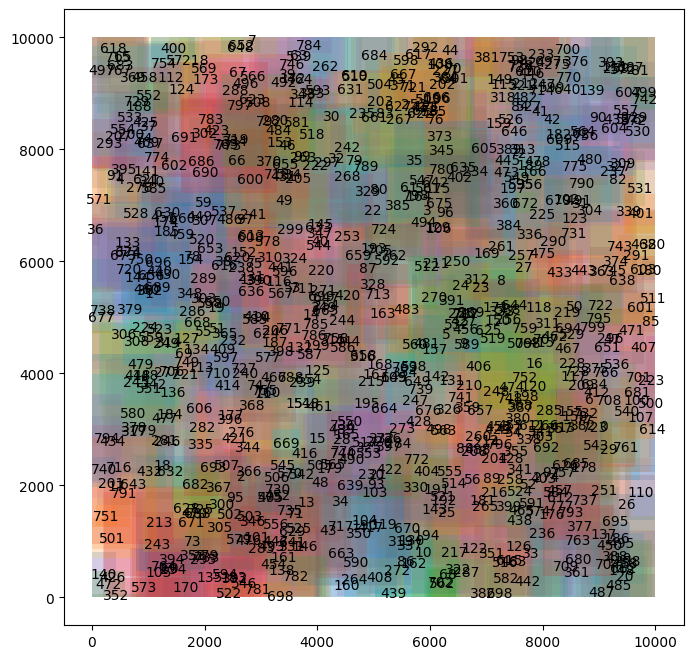

(415.80416157907626, 332643.329263261)

In [37]:
mypolygons: list[MyPolygon] = []
for v, (l, r, t, b) in enumerate(env.rectangles):
    mypolygons.append(MyPolygon(env.rectangles[v], v))
draw_mypolygon(mypolygons)


def estimate_point_cost(env, mypolygons):
    all_dist = []
    for n in range(env.N):
        c = env.coordinates[n]
        p = mypolygons[n].polygon.centroid
        all_dist.append(calc_dist(c, (p.x, p.y)))
    total = sum(all_dist)
    ave = sum(all_dist) / len(all_dist)
    return ave, total


estimate_point_cost(env, mypolygons)

In [38]:
poly_centeroid_dists = [(v, poly.get_polygon_distance()) for v, poly in enumerate(mypolygons)]
poly_centeroid_dists = sorted(poly_centeroid_dists, key=lambda x: x[1])
short_dist_points = poly_centeroid_dists[:100]
long_dist_points = poly_centeroid_dists[100:]

In [39]:
for i in range(100000):
    if i % 1000 == 0:
        print(f"{i} / 100000")
    # query_points = random.choices(short_dist_points, k=12)
    # query_points += random.choices(long_dist_points, k=3)
    query_points = random.choices(poly_centeroid_dists, k=3)
    query_points = [v for v, d in query_points]

    edges = env.query(query_points)
    my_graph = MyGraph(edges)

    for ei in range(len(edges)):
        v1, v2, group1, group2 = my_graph.cut_graph(ei)
        dist = mypolygons[v1].polygon.distance(mypolygons[v2].polygon)
        for gv1 in group1:
            for gv2 in group2:
                if gv1 == gv2:
                    continue
                mypolygons[gv1].remove_polygon(mypolygons[gv2], dist)
                mypolygons[gv2].remove_polygon(mypolygons[gv1], dist)
        # for gv2 in group2:
        #     if gv2 == v2:
        #         continue
        #     mypolygons[v1].remove_polygon(mypolygons[gv2], dist)
        # for gv1 in group1:
        #     if gv1 == v1:
        #         continue
        #     mypolygons[v2].remove_polygon(mypolygons[gv1], dist)

0 / 100000
1000 / 100000
2000 / 100000
3000 / 100000
4000 / 100000
5000 / 100000
6000 / 100000
multi
7000 / 100000
8000 / 100000
9000 / 100000
10000 / 100000
11000 / 100000
12000 / 100000
13000 / 100000
14000 / 100000
15000 / 100000
16000 / 100000
17000 / 100000
18000 / 100000
19000 / 100000
20000 / 100000
21000 / 100000
22000 / 100000
23000 / 100000
24000 / 100000
25000 / 100000
26000 / 100000
27000 / 100000
28000 / 100000
29000 / 100000
30000 / 100000
31000 / 100000
32000 / 100000
33000 / 100000
34000 / 100000
35000 / 100000
36000 / 100000
37000 / 100000
38000 / 100000
39000 / 100000
40000 / 100000
41000 / 100000
42000 / 100000
43000 / 100000
44000 / 100000
45000 / 100000
46000 / 100000
47000 / 100000
48000 / 100000
49000 / 100000
50000 / 100000
51000 / 100000
52000 / 100000
53000 / 100000
54000 / 100000
55000 / 100000
56000 / 100000
57000 / 100000
58000 / 100000
59000 / 100000
60000 / 100000
61000 / 100000
62000 / 100000
63000 / 100000
64000 / 100000
65000 / 100000
66000 / 100000
67

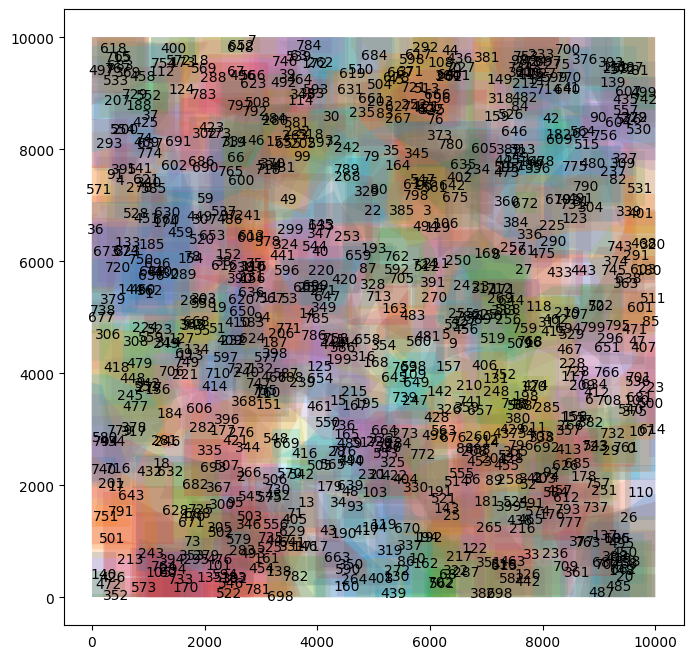

(331.9451670170609, 265556.1336136487)

In [40]:
draw_mypolygon(mypolygons)
estimate_point_cost(env, mypolygons)

In [41]:
def calc_greedy_answer(env: EnvOffline, target_points):
    graph: list[list[float]] = [[0 for _ in range(env.N)] for _ in range(env.N)]
    for i in range(env.N):
        for j in range(env.N):
            if i == j:
                continue
            dist = calc_dist(target_points[i], target_points[j])
            graph[i][j] = dist
            graph[j][i] = dist

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, _ = prim_k(graph, v, group_size, now_used, env.N)

        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges

In [42]:
target_points = []
for mypol in mypolygons:
    x, y = mypol.polygon.centroid.xy
    target_points.append((x[0], y[0]))

ans_v, ans_edges = calc_greedy_answer(env, target_points)
env.answer(ans_v, ans_edges)

446813.92592753726